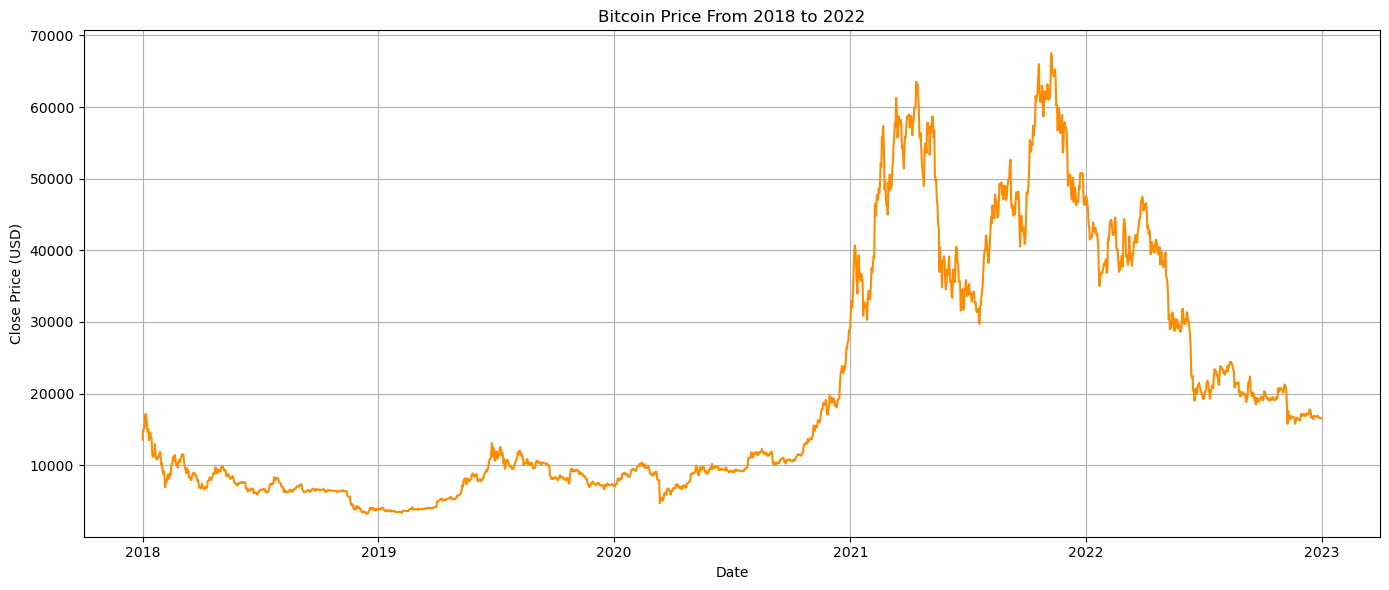

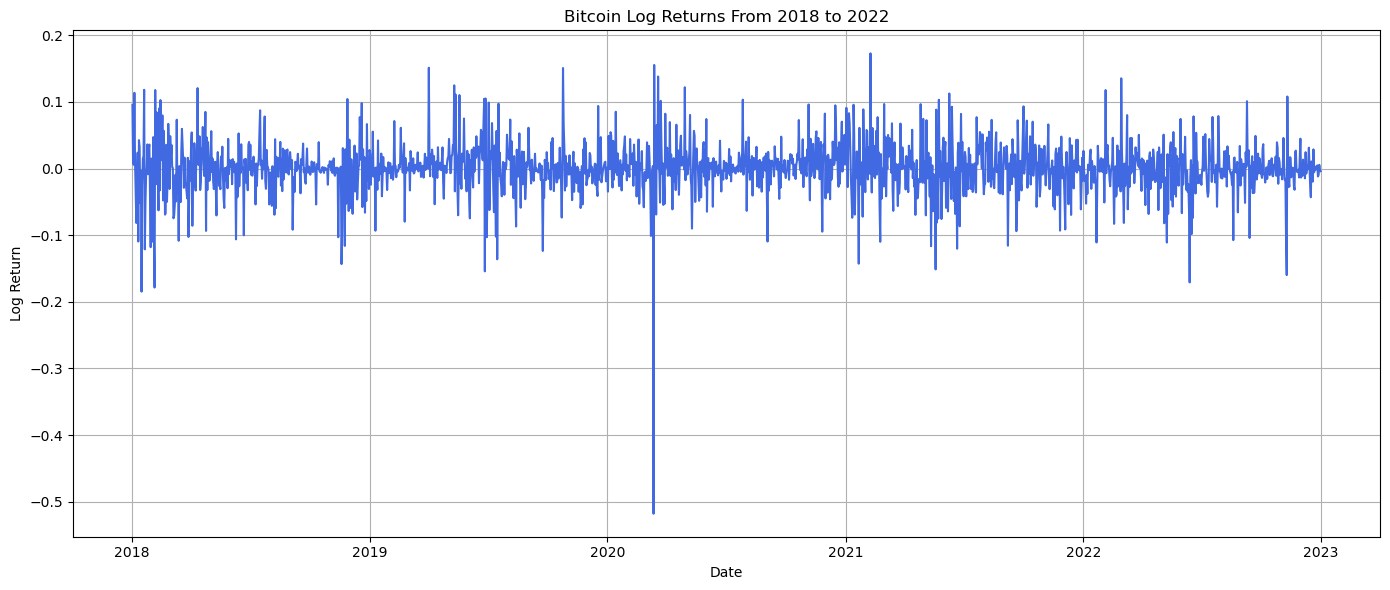

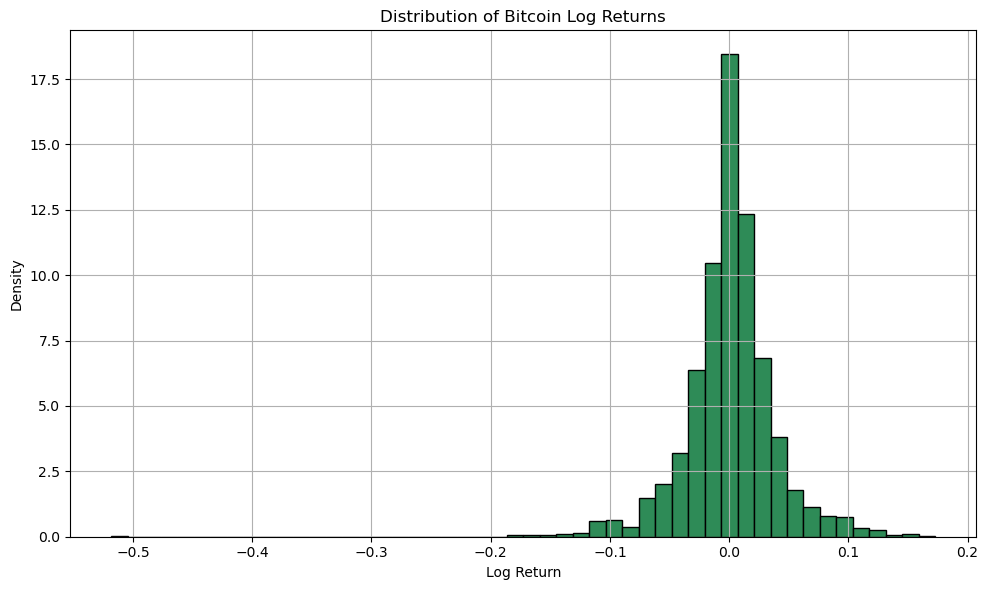

       Mean  Standard Deviation  Skewness   Kurtosis   Minimum   Maximum
0  0.000108            0.039499 -1.381481  18.258512 -0.518084  0.172829


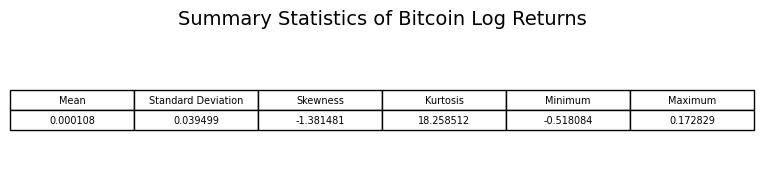

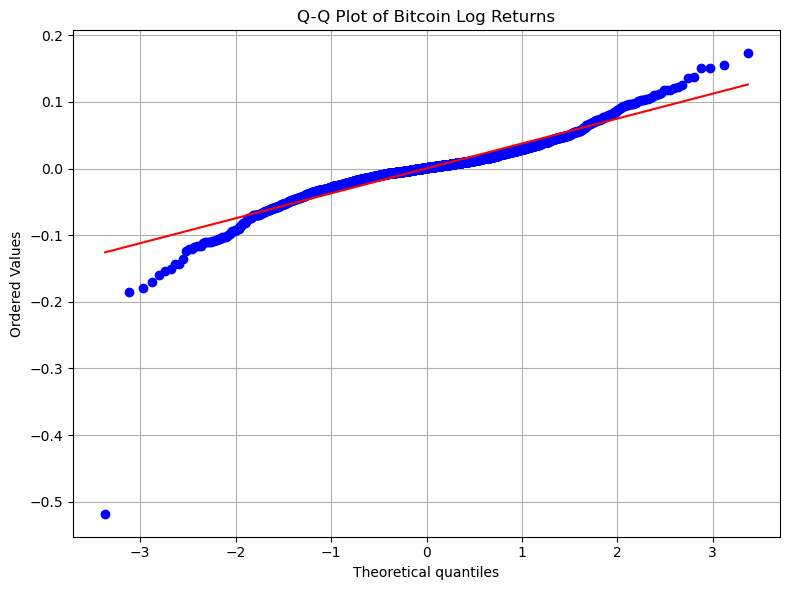

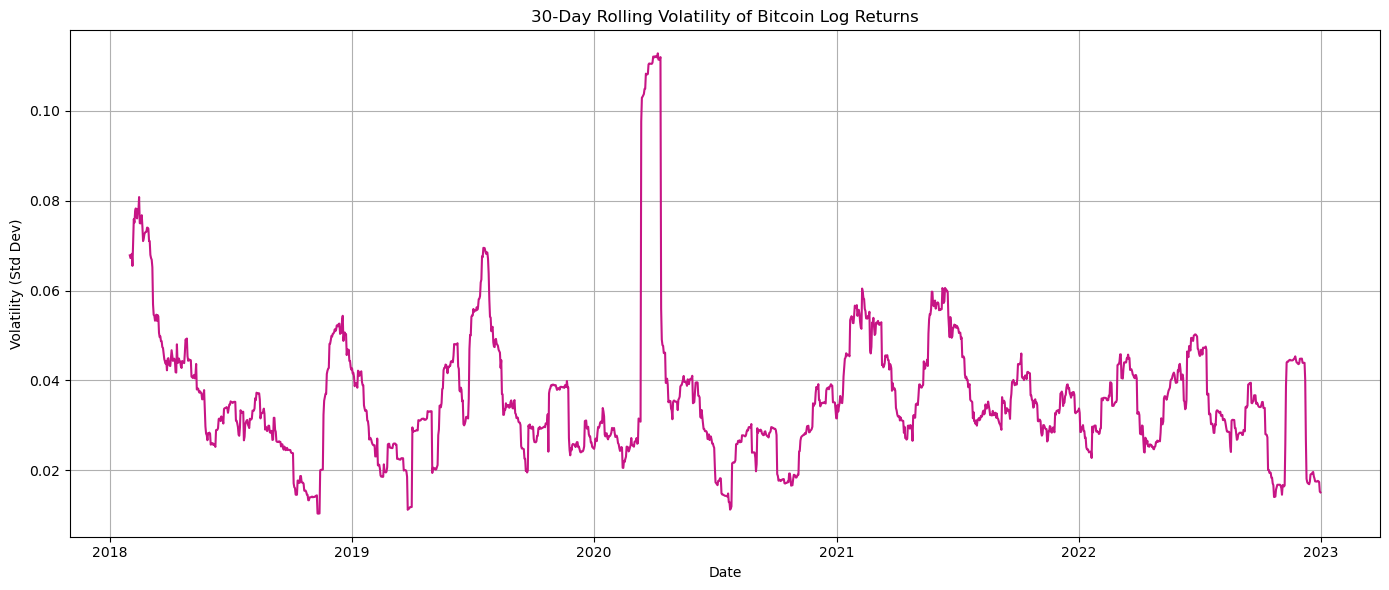

<Figure size 1000x600 with 0 Axes>

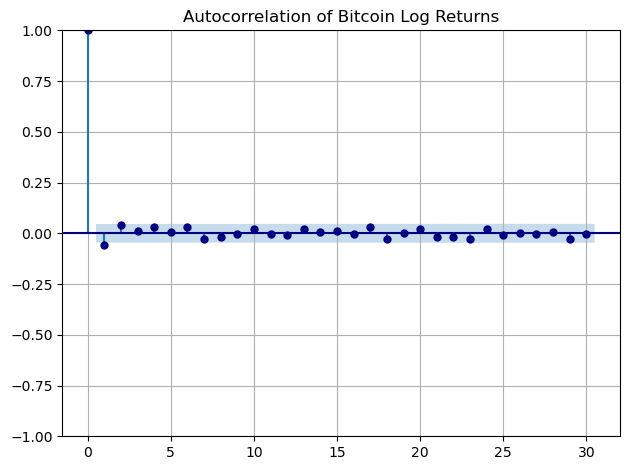

<Figure size 1000x600 with 0 Axes>

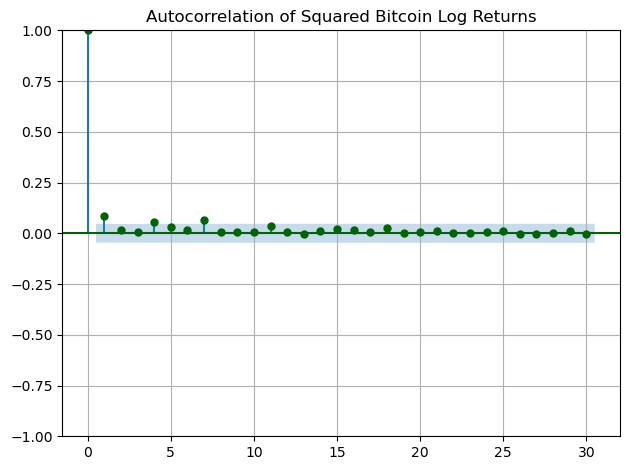

ADF Statistic: -20.485881144994412
p-value: 0.0
Used Lag: 3
Number of Observations: 1821


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

# Read the dataset
file_path = r'C:\Users\thinkpad\Desktop\学习文件\大三\ST312\Bitcoinclose.xlsx'
data = pd.read_excel(file_path)

# Rename columns if necessary
data.columns = ['Date', 'Close']

# Convert 'Date' to datetime and sort
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').reset_index(drop=True)

# Calculate Log Returns
data['LogReturn'] = np.log(data['Close'] / data['Close'].shift(1))
log_returns = data['LogReturn'].dropna()

# Plot 1: Bitcoin Price Over Time
plt.figure(figsize=(14, 6))
plt.plot(data['Date'], data['Close'], color='darkorange')
plt.title('Bitcoin Price From 2018 to 2022')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Bitcoin Log Returns Over Time
plt.figure(figsize=(14, 6))
plt.plot(data['Date'].iloc[1:], log_returns, color='royalblue')
plt.title('Bitcoin Log Returns From 2018 to 2022')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: Distribution of Bitcoin Log Returns
plt.figure(figsize=(10, 6))
plt.hist(log_returns, bins=50, color='seagreen', edgecolor='black', density=True)
plt.title('Distribution of Bitcoin Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Density')
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary Statistics
summary_stats = {
    'Mean': log_returns.mean(),
    'Standard Deviation': log_returns.std(),
    'Skewness': skew(log_returns),
    'Kurtosis': kurtosis(log_returns),
    'Minimum': log_returns.min(),
    'Maximum': log_returns.max(),
}
summary_df = pd.DataFrame(summary_stats, index=[0])
print(summary_df)

# Create styled dataframe
fig, ax = plt.subplots(figsize=(8, 1.5))  
ax.axis('tight')
ax.axis('off')
table = ax.table(
    cellText=summary_df.round(6).values,
    colLabels=summary_df.columns,
    cellLoc='center',
    loc='center'
)
table.scale(1.2, 1.2)  
plt.title('Summary Statistics of Bitcoin Log Returns', fontsize=14, pad=20)
plt.show()


# Plot 4: Q-Q Plot
plt.figure(figsize=(8, 6))
stats.probplot(log_returns, dist="norm", plot=plt)
plt.title("Q-Q Plot of Bitcoin Log Returns")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 5: 30-Day Rolling Volatility
rolling_vol = log_returns.rolling(window=30).std()
plt.figure(figsize=(14, 6))
plt.plot(data['Date'].iloc[1:], rolling_vol, color='mediumvioletred')
plt.title('30-Day Rolling Volatility of Bitcoin Log Returns')
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 6: ACF plot of returns
plt.figure(figsize=(10, 6))
plot_acf(log_returns, lags=30, color='navy')
plt.title('Autocorrelation of Bitcoin Log Returns')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 7: ACF plot of squared returns
plt.figure(figsize=(10, 6))
plot_acf(log_returns**2, lags=30, color='darkgreen')
plt.title('Autocorrelation of Squared Bitcoin Log Returns')
plt.grid(True)
plt.tight_layout()
plt.show()

# Perform ADF test
adf_result = adfuller(log_returns)
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Used Lag: {adf_result[2]}")
print(f"Number of Observations: {adf_result[3]}")
